# FNCE 449 Day 1 Assignment: Pairs Trading

**Assignment Instructions:**

1. **Select two correlated instruments and download data**
    - Download two years of data (e.g., July 1, 2023, to July 1, 2025) for two correlated instruments from Databento.
    - **Save the files locally to prevent querying Databento each time you run the code**.
    - Use hourly OHLCV data to enable higher frequency trading.

2. **Train the quantitative model**
   - Use only the *first* year of data to train the model.
   - Compute the price ratio $R_t=\frac{P_A}{P_B}$ and estimate the in-class regression: $$R_t-R_{t-1}=c-d \times R_{t-1} + \epsilon$$.
   - Set the threshold ratio for trading $\frac{c}{d}$.

3. **Implement the strategy**
    - Use only the *second* year of data to implement the model.
    - When $R_t>\frac{c}{d}$, then buy one stock $B$ and go short one stock $A$.
    - When $R_t<\frac{c}{d}$, buy one stock $A$ and go short one stock $B$.
    - Do not exceed one stock position at any time.
    - Keep track of your cash flow and mark-to-market your position over time.

4. **Performance Evaluation**
   - Calculate and plot the dollar value of your long-short portfolio over time.
   - Plot the number of trades over time.

In [16]:
import os
from io import StringIO

import pandas as pd
import requests
from requests.auth import HTTPBasicAuth

api_key = "db-RRkejP3pLR83aa7vkrtyTndLCNaey"
dataset = "XNAS.ITCH"
symbols = "NVDA,AMD"
schema = "ohlcv-1h"
start = "2024-07-01"
end = "2026-07-01"


def get_range(api_key, dataset, symbols, schema, start, end, limit=None):
    """Query the Databento historical API and return the result as a DataFrame."""
    url = "https://hist.databento.com/v0/timeseries.get_range"
    auth = HTTPBasicAuth(api_key, "")

    payload = {
        "dataset": dataset,
        "symbols": symbols,
        "schema": schema,
        "start": start,
        "end": end,
        "encoding": "csv",
        "pretty_px": "true",
        "pretty_ts": "true",
        "map_symbols": "true",
        "limit": limit,
    }

    response = requests.post(url, auth=auth, data=payload)
    response.raise_for_status()
    return pd.read_csv(StringIO(response.content.decode("utf-8")))


# Download once, then save one local CSV per stock.
# This keeps the data cleaner for the pairs-trading assignment.
file_path = "NVDA_AMD_hourly_2024_2026.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Loaded combined local data from {file_path}")
else:
    df = get_range(api_key, dataset, symbols, schema, start, end)
    df.to_csv(file_path, index=False)
    print(f"Downloaded and saved {len(df)} rows to {file_path}")

if "ts_event" in df.columns:
    df["ts_event"] = pd.to_datetime(df["ts_event"])

# Keep only the columns needed for the assignment
cols = ["ts_event", "symbol", "open", "high", "low", "close", "volume"]
for c in cols:
    if c not in df.columns:
        raise ValueError(f"Missing expected column: {c}")

df = df[cols].copy().sort_values("ts_event").reset_index(drop=True)

for sym, group in df.groupby("symbol"):
    path = f"{sym}_hourly_2024_2026.csv"
    group.to_csv(path, index=False)
    print(f"Saved {len(group)} rows to {path}")

print(df.head())


Loaded combined local data from NVDA_AMD_hourly_2024_2026.csv
Saved 7833 rows to AMD_hourly_2024_2026.csv
Saved 7833 rows to NVDA_hourly_2024_2026.csv
                   ts_event symbol    open    high     low   close  volume
0 2024-07-01 08:00:00+00:00   NVDA  124.02  124.26  120.57  121.36  670562
1 2024-07-01 08:00:00+00:00    AMD  162.33  163.29  160.40  161.70   20775
2 2024-07-01 09:00:00+00:00   NVDA  121.35  121.73  120.01  121.27  591873
3 2024-07-01 09:00:00+00:00    AMD  161.87  162.00  161.00  161.71   17455
4 2024-07-01 10:00:00+00:00   NVDA  121.21  121.85  121.05  121.70  257863


In [ ]:
import numpy as np
import statsmodels.api as sm

# Read the two saved symbol files.
# We use the first year for model training and the second year for implementation.
A_symbol = "NVDA"
B_symbol = "AMD"

nvda = pd.read_csv(f"{A_symbol}_hourly_2024_2026.csv", parse_dates=["ts_event"]).sort_values("ts_event").set_index("ts_event")
amd = pd.read_csv(f"{B_symbol}_hourly_2024_2026.csv", parse_dates=["ts_event"]).sort_values("ts_event").set_index("ts_event")

# Use close prices only, and align by timestamp.
price_df = pd.concat({A_symbol: nvda["close"], B_symbol: amd["close"]}, axis=1).dropna()
price_df.columns = ["P_A", "P_B"]

# Ratio process: R_t = P_A / P_B
price_df["R_t"] = price_df["P_A"] / price_df["P_B"]
price_df["R_t_lag"] = price_df["R_t"].shift(1)
price_df["delta_R_t"] = price_df["R_t"] - price_df["R_t_lag"]

# Use only the first year for the in-sample regression.
# Notebook A uses a linear model with an intercept and one regressor.
# Here: delta_R_t = c - d * R_t_lag + epsilon
train = price_df[(price_df.index >= "2024-07-01") & (price_df.index < "2025-07-01")].dropna()

X = sm.add_constant(train["R_t_lag"])
model = sm.OLS(train["delta_R_t"], X).fit()

c_est = model.params.iloc[0]
slope = model.params.iloc[1]
d_est = -slope
threshold = c_est / d_est if abs(d_est) > 0 else np.nan

print(f"Estimated c = {c_est:.6f}")
print(f"Estimated d = {d_est:.6f}")
print(f"Trading threshold c/d = {threshold:.6f}")
print(model.summary())
print(train[["P_A", "P_B", "R_t", "R_t_lag", "delta_R_t"]].head())


Estimated c = 0.001156
Estimated d = 0.001057
Trading threshold c/d = 1.093296
                              P_A     P_B       R_t   R_t_lag  delta_R_t
ts_event                                                                
2024-07-01 09:00:00+00:00  121.27  161.71  0.749923  0.750526  -0.000603
2024-07-01 10:00:00+00:00  121.70  162.15  0.750540  0.749923   0.000617
2024-07-01 11:00:00+00:00  122.22  162.58  0.751753  0.750540   0.001213
2024-07-01 12:00:00+00:00  123.60  162.62  0.760054  0.751753   0.008301
2024-07-01 13:00:00+00:00  120.59  155.37  0.776147  0.760054   0.016093


Estimated threshold c/d = 1.093296
                              P_A     P_B       R_t  signal  spread_gap  \
ts_event                                                                  
2025-07-01 08:00:00+00:00  157.18  141.00  1.114752       1    0.021456   
2025-07-01 09:00:00+00:00  156.86  139.45  1.124848       1    0.031552   
2025-07-01 10:00:00+00:00  156.71  139.65  1.122163       1    0.028867   
2025-07-01 11:00:00+00:00  156.61  139.72  1.120885       1    0.027589   
2025-07-01 12:00:00+00:00  156.42  138.43  1.129957       1    0.036662   

                           trade_pnl  portfolio_value  
ts_event                                               
2025-07-01 08:00:00+00:00  21.456150        21.456150  
2025-07-01 09:00:00+00:00  31.551993        53.008143  
2025-07-01 10:00:00+00:00  28.866926        81.875069  
2025-07-01 11:00:00+00:00  27.589004       109.464073  
2025-07-01 12:00:00+00:00  36.661756       146.125829  
Total number of trades in the second year: 54


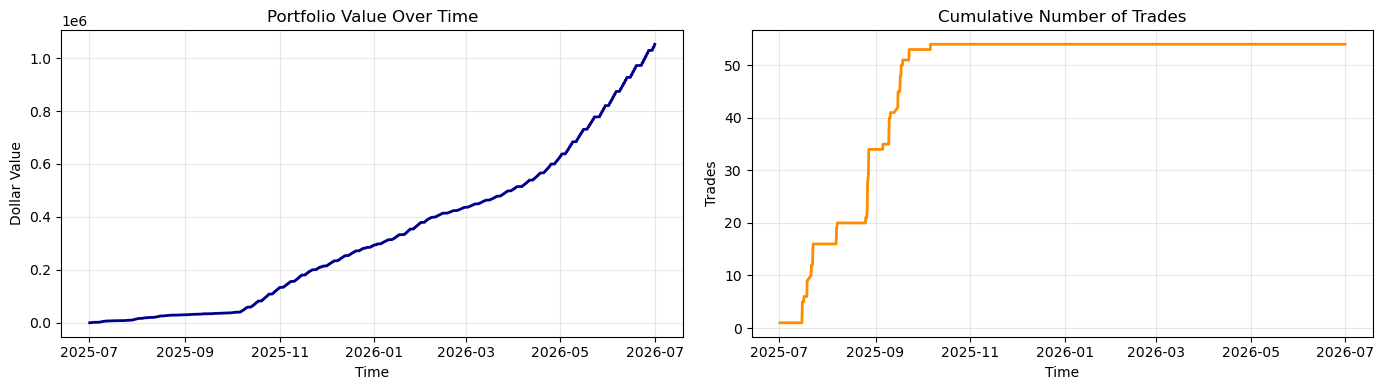

In [18]:
# Use the second year for live implementation of the strategy.
# The threshold comes from the in-sample regression estimated in the first year.
# We do NOT re-estimate OLS in the second year; that would leak information from the test period.

if "threshold" not in globals() or pd.isna(threshold):
    raise ValueError("Run the training cell first so that 'threshold' is defined.")

test = price_df[(price_df.index >= "2025-07-01") & (price_df.index < "2026-07-01")].copy().dropna()

test["signal"] = np.where(test["R_t"] > threshold, 1, -1)

# A perfectly hedged pair trade has equal dollar exposure long and short,
# so the net market value is mechanically near zero. The economically relevant
# quantity is cumulative PnL from the spread relative to the threshold.
notional = 1000.0

test["spread_gap"] = test["R_t"] - threshold
# Sign of PnL is aligned with the trade direction.
test["trade_pnl"] = test["signal"] * test["spread_gap"] * notional
# Cumulative PnL over time is what moves.
test["portfolio_value"] = test["trade_pnl"].cumsum()

test["trade_flag"] = (test["signal"] != test["signal"].shift(1)).fillna(0).astype(int)
test["cumulative_trades"] = test["trade_flag"].cumsum()

print(f"Estimated threshold c/d = {threshold:.6f}")
print(test[["P_A", "P_B", "R_t", "signal", "spread_gap", "trade_pnl", "portfolio_value"]].head())
print(f"Total number of trades in the second year: {int(test['trade_flag'].sum())}")

# Final evaluation plots required by the assignment.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test.index, test["portfolio_value"], color="darkblue", linewidth=2)
axes[0].set_title("Portfolio Value Over Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Dollar Value")
axes[0].grid(True, alpha=0.3)

axes[1].plot(test.index, test["cumulative_trades"], color="darkorange", linewidth=2)
axes[1].set_title("Cumulative Number of Trades")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Trades")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
